# LAB-D3-03: Make It Overfit, Then Rescue It - Instructor Solution

> **Instructor only.** This notebook contains completed responses and teaching notes. Do not distribute it with participant materials.

**Purpose:** Intentionally create a visible generalization gap, choose exactly one remedy, and evaluate matched before/after evidence.

**Objectives:** `OBJ-D3-04`, `OBJ-D3-05`; reinforces `OBJ-D3-01`  
**Estimated duration:** 55 minutes live; baseline plus one intervention under 10 minutes CPU  
**Prerequisites:** [LESSON-D3-04](../../day-3/student-guide/day-3-student-guide.md#lesson-d3-04---training-deep-networks-read-the-evidence), [LESSON-D3-05](../../day-3/student-guide/day-3-student-guide.md#lesson-d3-05---overfitting-rescue-and-generalization), and `LAB-D3-02` concepts; no prior notebook state required  
**Environment:** CPU; PyTorch/torchvision; packaged Fashion-MNIST fallback; cache/download path optional

Workflow: **Predict failure -> Train high-capacity/tiny-data baseline -> Locate gap -> Choose one remedy -> Match budget -> Compare -> Accept or reject**. A failed remedy is acceptable evidence when the experiment is controlled and diagnosed.

## Instructor Briefing

**What and why:** The baseline intentionally combines high capacity with only 400 balanced training images. Near-perfect training fit plus stalled/rising validation loss creates observable overfitting. The core experiment then changes exactly one major factor so any before/after difference has a defensible interpretation.

**Expected fallback evidence:** mode `packaged_fashion_mnist_fallback`; `400` training and `800` validation images; baseline model `535,818` parameters; final baseline approximately train `0.998`, validation `0.796`, gap `0.201`; validation loss bottoms near epoch 7 and rises while training loss approaches zero. This solution selects dropout `0.4`: approximately train `0.985`, validation `0.799`, gap `0.186`. Those deltas do not meet the predeclared `+0.03` validation or `-0.05` gap criterion, so the correct conclusion is to reject the remedy at this strength while retaining the negative result.

**Source boundary:** the packaged data execute the overfit and one-remedy mechanics, but they do not validate an online Fashion-MNIST metric band or hosted Colab runtime. Keep source mode attached to every reported number.

**Hint ladder:**
1. Compare training and validation trajectories on the same epoch axis; high training accuracy alone is not the diagnosis.
2. Locate the minimum validation loss and ask what happens afterward while training loss continues down.
3. Write one mechanism prediction before selecting a remedy.
4. If the validator rejects the configuration, count changed major factors and retain only one.
5. Apply the acceptance rule exactly as declared; do not rewrite it after seeing the curves.

**Likely misconceptions:** overfitting means optimization failed; any smaller gap is a successful rescue; lower training accuracy is automatically better; combining dropout, weight decay, and a smaller model is stronger evidence; a negative result should be hidden; augmentation may be applied to validation for symmetry.

**Discussion triggers:** What evidence separates overfitting from underfitting? Why is validation loss more revealing than the final accuracy alone here? Which next single experiment has the highest information value after dropout misses the criterion?

**Troubleshooting, recovery, and alternatives:** Restore the supplied 400-example split, 24-epoch budget, widths, and seed if the baseline no longer overfits. Exactly one of dropout, weight decay, smaller capacity, training-only augmentation, or early stopping can be a valid alternative when its mechanism and matched controls are explicit; early stopping must restore the best validation checkpoint. The optional augmentation cell is a plan, not a second core intervention. If time is short, run the baseline and supplied dropout comparison, then discuss the predeclared decision. CPU is the required baseline; GPU timing and nondeterminism require separate calibration.

In [1]:
%matplotlib inline
import platform
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

DATA_SEED = 3301
MODEL_SEED = 3302
BATCH_SEED = 3303
DEVICE = torch.device("cpu")
ALLOW_DOWNLOAD = False
TINY_TRAIN_COUNT = 400
VALIDATION_COUNT = 800
EPOCHS = 24
BATCH_SIZE = 64
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.2})

def set_all_seeds(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

set_all_seeds(MODEL_SEED)
print(f"Python {platform.python_version()} | torch {torch.__version__} | torchvision {torchvision.__version__}")
print("Required device: CPU; optional accelerators do not change the experiment budget.")

Python 3.11.8 | torch 2.6.0 | torchvision 0.21.0
Required device: CPU; optional accelerators do not change the experiment budget.


## Independent Data Setup

This notebook may reuse the torchvision cache created for `LAB-D3-02`, but never its variables or model. It loads data again and falls back to the packaged balanced subset. From either source, it samples exactly 400 stratified training images and 800 validation images.

In [2]:
from pathlib import Path

def find_repo_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "courseware/shared/data/day-3/manifest.json").exists():
            return candidate
    raise FileNotFoundError(
        "Day 3 support files are missing. Run from a repository checkout and see courseware/shared/environment.md."
    )

def balanced_indices(labels, count, seed):
    labels = np.asarray(labels)
    classes = np.unique(labels)
    rng = np.random.default_rng(seed)
    per_class = count // len(classes)
    selected = np.concatenate([
        rng.choice(np.flatnonzero(labels == class_id), size=per_class, replace=False)
        for class_id in classes
    ])
    return selected[rng.permutation(len(selected))]

def load_fashion_splits(allow_download=False):
    repo_root = find_repo_root()
    cache_root = repo_root / ".cache/day-3/torchvision"
    source_error = None
    try:
        from torchvision.datasets import FashionMNIST
        train_source = FashionMNIST(cache_root, train=True, download=allow_download)
        test_source = FashionMNIST(cache_root, train=False, download=allow_download)
        train_images_all = train_source.data.numpy()
        train_labels_all = train_source.targets.numpy()
        test_images_all = test_source.data.numpy()
        test_labels_all = test_source.targets.numpy()
        pool = balanced_indices(train_labels_all, 12000, DATA_SEED)
        train_indices, val_indices = train_test_split(
            pool, train_size=10000, test_size=2000, stratify=train_labels_all[pool], random_state=DATA_SEED
        )
        test_indices = balanced_indices(test_labels_all, 2000, DATA_SEED + 1)
        arrays = {
            "train_images": train_images_all[train_indices], "train_labels": train_labels_all[train_indices],
            "val_images": train_images_all[val_indices], "val_labels": train_labels_all[val_indices],
            "test_images": test_images_all[test_indices], "test_labels": test_labels_all[test_indices],
            "class_names": np.asarray(train_source.classes),
        }
        mode = "fashion_mnist_cache_or_opt_in_download"
    except Exception as error:
        source_error = str(error)
        fallback_path = repo_root / "courseware/shared/data/day-3/fashion_mnist_fallback.npz"
        loaded = np.load(fallback_path, allow_pickle=False)
        arrays = {name: loaded[name] for name in loaded.files if name not in {"seed"}}
        mode = "packaged_fashion_mnist_fallback"
    mean = float(arrays["train_images"].mean() / 255.0)
    std = float(arrays["train_images"].std() / 255.0)
    def as_tensor(images):
        values = torch.tensor(images, dtype=torch.float32).unsqueeze(1) / 255.0
        return (values - mean) / std
    tensors = {
        "X_train": as_tensor(arrays["train_images"]),
        "y_train": torch.tensor(arrays["train_labels"], dtype=torch.long),
        "X_val": as_tensor(arrays["val_images"]),
        "y_val": torch.tensor(arrays["val_labels"], dtype=torch.long),
        "X_test": as_tensor(arrays["test_images"]),
        "y_test": torch.tensor(arrays["test_labels"], dtype=torch.long),
        "class_names": list(arrays["class_names"]),
        "mode": mode,
        "source_error": source_error,
        "mean": mean,
        "std": std,
    }
    return tensors

In [3]:
source = load_fashion_splits(ALLOW_DOWNLOAD)
tiny_indices = balanced_indices(source["y_train"].numpy(), TINY_TRAIN_COUNT, DATA_SEED + 10)
val_indices = balanced_indices(source["y_val"].numpy(), VALIDATION_COUNT, DATA_SEED + 11)
X_tiny, y_tiny = source["X_train"][tiny_indices], source["y_train"][tiny_indices]
X_val, y_val = source["X_val"][val_indices], source["y_val"][val_indices]
assert X_tiny.shape == (400, 1, 28, 28) and X_val.shape == (800, 1, 28, 28)
assert torch.bincount(y_tiny, minlength=10).tolist() == [40] * 10
print("Source mode:", source["mode"])
print("Tiny/validation shapes:", X_tiny.shape, X_val.shape)

Source mode: packaged_fashion_mnist_fallback
Tiny/validation shapes: torch.Size([400, 1, 28, 28]) torch.Size([800, 1, 28, 28])


## Predict the Spectacular Failure

The baseline has more than half a million parameters and only 400 training images. Sketch the expected train/validation curves, predict the final generalization gap, and name evidence that would distinguish overfitting from optimization failure.

In [4]:
overfit_predictions = {
    "train_curve": "Training loss should approach zero and training accuracy should approach one.",
    "validation_curve": "Validation should improve early, then stall or worsen while training continues improving.",
    "train_accuracy_band": ">0.98",
    "validation_accuracy_band": "0.65-0.82",
    "gap_band": ">=0.15",
    "overfit_vs_optimization_check": "Strong training fit with weak validation supports overfitting; weak fit on both would suggest optimization or representation failure.",
}
assert all(value.strip() for value in overfit_predictions.values())

## Modify: Define Capacity Explicitly

Complete `CapacityNet`. The baseline uses hidden widths `(512,256)` and optional dropout `0.0`. A smaller-model remedy later uses the same class with `(128,64)`. Return raw ten-class logits.

In [5]:
class CapacityNet(nn.Module):
    def __init__(self, hidden_1=512, hidden_2=256, dropout=0.0):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_1, hidden_2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_2, 10),
        )

    def forward(self, images):
        return self.network(images)

baseline_model = CapacityNet().to(DEVICE)
baseline_parameter_count = sum(parameter.numel() for parameter in baseline_model.parameters())
assert baseline_model(X_tiny[:8]).shape == (8, 10)
assert baseline_parameter_count > 500_000
print(f"Baseline parameters: {baseline_parameter_count:,}")

Baseline parameters: 535,818


## Training Harness

Complete `fit_model`. Each run must reset seeds, use a newly constructed model/optimizer/loader, call train/eval modes explicitly, and record train/validation loss and accuracy once per epoch. The harness accepts weight decay so that one remedy can change optimizer regularization without changing data or epoch budget.

In [6]:
loss_fn = nn.CrossEntropyLoss()

def evaluate(model, X, y):
    model.eval()
    with torch.inference_mode():
        logits = model(X)
        return float(loss_fn(logits, y).item()), float((logits.argmax(1) == y).float().mean().item())

def fit_model(model, *, weight_decay=0.0, epochs=EPOCHS):
    set_all_seeds(MODEL_SEED)
    generator = torch.Generator().manual_seed(BATCH_SEED)
    loader = DataLoader(
        TensorDataset(X_tiny, y_tiny),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)
    history = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}
    for _epoch in range(epochs):
        model.train()
        for images, targets in loader:
            optimizer.zero_grad()
            logits = model(images.to(DEVICE))
            loss = loss_fn(logits, targets.to(DEVICE))
            loss.backward()
            optimizer.step()
        train_loss, train_accuracy = evaluate(model, X_tiny, y_tiny)
        val_loss, val_accuracy = evaluate(model, X_val, y_val)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)
    return history

In [7]:
set_all_seeds(MODEL_SEED)
baseline_started = time.perf_counter()
baseline_model = CapacityNet().to(DEVICE)
baseline_history = fit_model(baseline_model)
baseline_seconds = time.perf_counter() - baseline_started
baseline_train_accuracy = baseline_history["train_accuracy"][-1]
baseline_val_accuracy = baseline_history["val_accuracy"][-1]
baseline_gap = baseline_train_accuracy - baseline_val_accuracy
print(f"Baseline: train={baseline_train_accuracy:.3f}, validation={baseline_val_accuracy:.3f}, gap={baseline_gap:.3f}, time={baseline_seconds:.2f}s")
assert baseline_train_accuracy > 0.98
assert 0.65 <= baseline_val_accuracy <= 0.82
assert baseline_gap >= 0.15

Baseline: train=0.998, validation=0.796, gap=0.201, time=0.21s


## Inspect the Baseline Before Choosing a Remedy

Identify the first epoch at which the validation loss reaches its minimum. Do not choose a remedy from final accuracy alone.

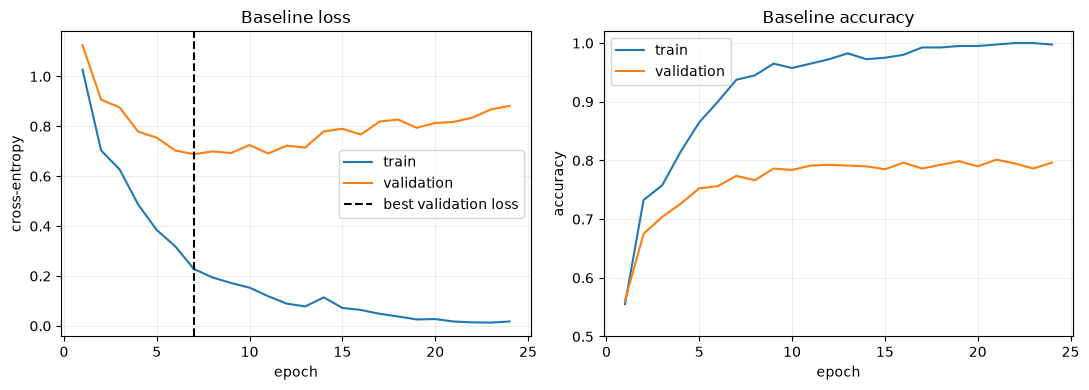

In [8]:
best_baseline_epoch = int(np.argmin(baseline_history["val_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
epochs_axis = np.arange(1, EPOCHS + 1)
axes[0].plot(epochs_axis, baseline_history["train_loss"], label="train")
axes[0].plot(epochs_axis, baseline_history["val_loss"], label="validation")
axes[0].axvline(best_baseline_epoch, color="black", linestyle="--", label="best validation loss")
axes[0].set(title="Baseline loss", xlabel="epoch", ylabel="cross-entropy"); axes[0].legend()
axes[1].plot(epochs_axis, baseline_history["train_accuracy"], label="train")
axes[1].plot(epochs_axis, baseline_history["val_accuracy"], label="validation")
axes[1].set(title="Baseline accuracy", xlabel="epoch", ylabel="accuracy", ylim=(0.5, 1.02)); axes[1].legend()
plt.tight_layout(); plt.show()

## Deliberate Failure: The Confounded Rescue

Applying dropout, weight decay, and a smaller model together may change the metric, but it cannot isolate a mechanism. Predict the design-check failure, then run the caught validator.

In [9]:
confounded_prediction = "ValueError because three remedies prevent attributing the result to one mechanism."
assert confounded_prediction.strip()

def validate_one_remedy(changes):
    active = [name for name, enabled in changes.items() if enabled]
    if len(active) != 1:
        raise ValueError(f"Core experiment requires exactly one remedy; received {active}")
    return active[0]

confounded_failure_observed = False
try:
    validate_one_remedy({"dropout": True, "weight_decay": True, "smaller_model": True})
except ValueError as error:
    confounded_failure_observed = True
    print("Expected experiment-design diagnostic:", error)
assert confounded_failure_observed

Expected experiment-design diagnostic: Core experiment requires exactly one remedy; received ['dropout', 'weight_decay', 'smaller_model']


## Challenge: Choose Exactly One Remedy

Select one of `dropout`, `weight_decay`, or `smaller_model`. State the mechanism, expected train/validation curve changes, an acceptance criterion, and evidence that would make you reject the hypothesis. Keep split, batch size, optimizer family, learning rate, seeds, and 24-epoch maximum fixed.

In [10]:
remedy_choice = "dropout"
remedy_plan = {
    "mechanism": "Randomly suppress hidden activations during training to reduce brittle co-adaptation.",
    "expected_train_change": "Training fit should be slower or lower than the unregularized baseline.",
    "expected_validation_change": "Validation may improve or deteriorate less after its best epoch.",
    "acceptance_criterion": "At least +0.03 validation accuracy or -0.05 gap without validation collapse.",
    "rejection_evidence": "Neither criterion is met, or both train and validation collapse.",
}
assert remedy_choice in {"dropout", "weight_decay", "smaller_model"}
assert all(value.strip() for value in remedy_plan.values())
active_remedy = validate_one_remedy({name: name == remedy_choice for name in ["dropout", "weight_decay", "smaller_model"]})

## Modify: Configure Only the Chosen Remedy

Complete `build_remedy`. Return `(model, weight_decay)`. Dropout uses `0.4`; weight decay uses `1e-3`; the smaller model uses widths `(128,64)`. Every other baseline setting must remain unchanged.

In [11]:
def build_remedy(choice):
    if choice == "dropout":
        return CapacityNet(dropout=0.4).to(DEVICE), 0.0
    if choice == "weight_decay":
        return CapacityNet().to(DEVICE), 1e-3
    if choice == "smaller_model":
        return CapacityNet(hidden_1=128, hidden_2=64).to(DEVICE), 0.0
    raise ValueError(f"Unknown remedy: {choice}")

set_all_seeds(MODEL_SEED)
remedy_model, remedy_weight_decay = build_remedy(remedy_choice)
remedy_parameter_count = sum(parameter.numel() for parameter in remedy_model.parameters())
remedy_started = time.perf_counter()
remedy_history = fit_model(remedy_model, weight_decay=remedy_weight_decay)
remedy_seconds = time.perf_counter() - remedy_started
remedy_train_accuracy = remedy_history["train_accuracy"][-1]
remedy_val_accuracy = remedy_history["val_accuracy"][-1]
remedy_gap = remedy_train_accuracy - remedy_val_accuracy
print(f"Remedy: train={remedy_train_accuracy:.3f}, validation={remedy_val_accuracy:.3f}, gap={remedy_gap:.3f}, time={remedy_seconds:.2f}s")

Remedy: train=0.985, validation=0.799, gap=0.186, time=0.21s


## Compare on Matched Axes and Budget

A smaller gap is useful only if it does not come from both train and validation performance collapsing. The same axes expose that distinction.

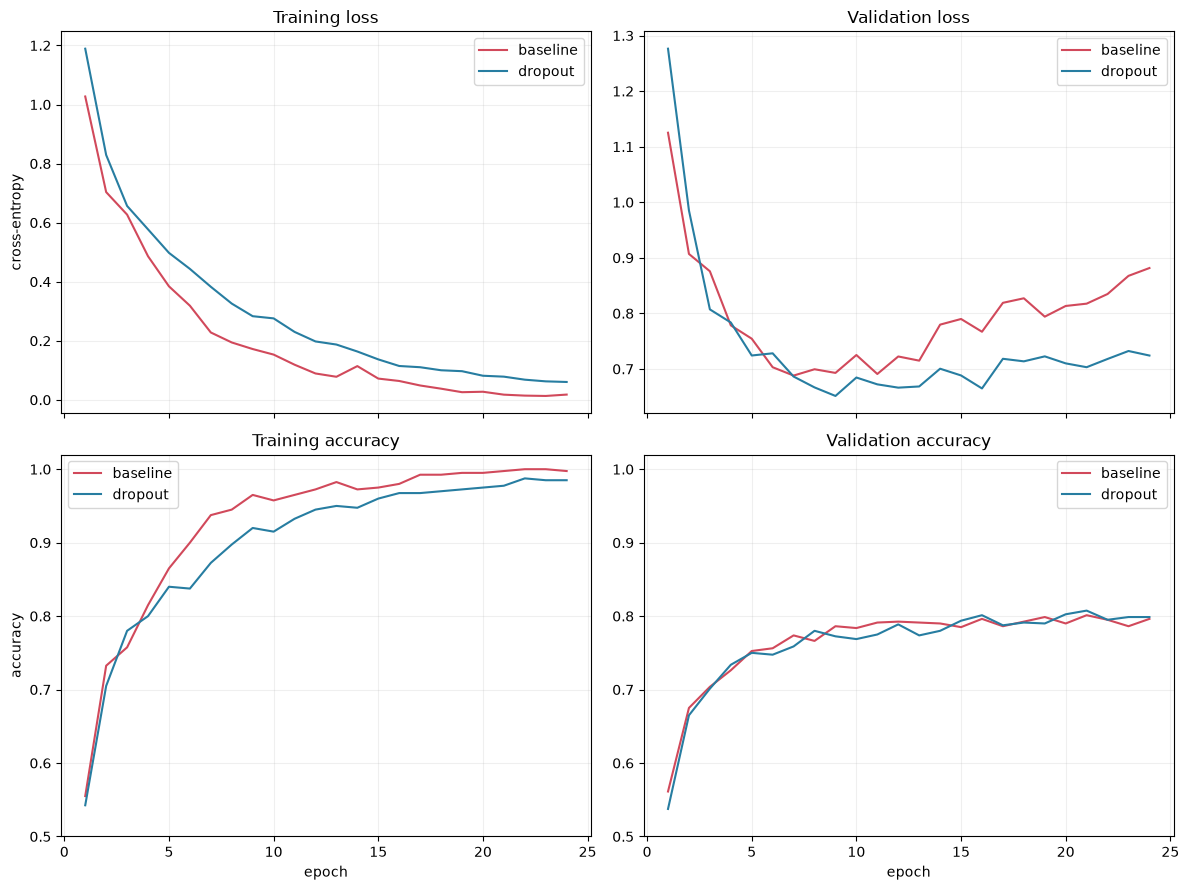

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
for history, label, color in [(baseline_history, "baseline", "#d1495b"), (remedy_history, remedy_choice, "#277da1")]:
    axes[0, 0].plot(epochs_axis, history["train_loss"], label=label, color=color)
    axes[0, 1].plot(epochs_axis, history["val_loss"], label=label, color=color)
    axes[1, 0].plot(epochs_axis, history["train_accuracy"], label=label, color=color)
    axes[1, 1].plot(epochs_axis, history["val_accuracy"], label=label, color=color)
axes[0, 0].set(title="Training loss", ylabel="cross-entropy")
axes[0, 1].set(title="Validation loss")
axes[1, 0].set(title="Training accuracy", xlabel="epoch", ylabel="accuracy", ylim=(0.5, 1.02))
axes[1, 1].set(title="Validation accuracy", xlabel="epoch", ylim=(0.5, 1.02))
for ax in axes.ravel(): ax.legend()
plt.tight_layout(); plt.show()

## Decide: Improvement, Trade-off, or No Improvement

A valid conclusion may be that the remedy did not improve validation. Use absolute validation performance, gap, curve shape, and parameter count where relevant. Do not relabel a negative result as success.

In [13]:
validation_delta = remedy_val_accuracy - baseline_val_accuracy
gap_delta = remedy_gap - baseline_gap
accepted = validation_delta >= 0.03 or (gap_delta <= -0.05 and remedy_val_accuracy >= baseline_val_accuracy)
remedy_diagnosis = {
    "accept_or_reject_hypothesis": "Accept under the stated criterion." if accepted else "Reject under the stated criterion; keep the controlled negative result.",
    "validation_evidence": f"Validation changed by {validation_delta:+.3f} ({baseline_val_accuracy:.3f} to {remedy_val_accuracy:.3f}).",
    "gap_evidence": f"The gap changed by {gap_delta:+.3f} ({baseline_gap:.3f} to {remedy_gap:.3f}).",
    "training_collapse_check": f"Remedy training accuracy was {remedy_train_accuracy:.3f} and validation was {remedy_val_accuracy:.3f}.",
    "mechanism_consistency": "Lower training fit is consistent with dropout pressure, but validation decides whether that pressure helped.",
    "next_single_experiment": "Test weight decay alone with the same split, seed, and epoch budget.",
}
assert all(value.strip() for value in remedy_diagnosis.values())

## Optional Extension: Training-Only Augmentation

Design, but do not combine, a small random translation or crop applied only to training images. State how you would verify that validation remains deterministic. This extension is planning-only so it cannot contaminate the core one-remedy comparison.

In [14]:
optional_augmentation_plan = {
    "transform": "Seeded random translation by at most two pixels, applied only while drawing training batches.",
    "training_only_check": "Evaluate the same validation index twice and assert identical tensors and logits.",
    "expected_curve_change": "Training accuracy may fall while validation improves if translation invariance is useful.",
}
if not any(value.strip() for value in optional_augmentation_plan.values()):
    print("Optional augmentation plan skipped. Core checkpoint is unaffected.")
else:
    assert all(value.strip() for value in optional_augmentation_plan.values())

## Reflect and Checkpoint

Explain why the baseline is overfitting rather than simply learning well, what the one-change rule buys, and why no improvement can still be an informative result.

In [15]:
reflection = {
    "overfit_evidence": "Training exceeds 0.98 while held-out accuracy remains much lower and validation loss bottoms out earlier.",
    "one_change_value": "Matched data, seeds, optimizer, and epochs make the dropout mechanism the main changed factor.",
    "failed_remedy_value": "A controlled failure rules out this dropout strength under this fixed budget.",
    "gap_alone_limit": "A gap can shrink because both scores collapse, so absolute validation performance also matters.",
}
assert all(value.strip() for value in reflection.values())
assert baseline_train_accuracy > 0.98
assert 0.65 <= baseline_val_accuracy <= 0.82
assert baseline_gap >= 0.15
assert active_remedy == remedy_choice
assert len(baseline_history["val_loss"]) == len(remedy_history["val_loss"]) == EPOCHS
assert baseline_seconds + remedy_seconds < 10 * 60
print("LAB-D3-03 checkpoint passed: reliable overfit baseline, exactly one matched-budget remedy, aligned evidence, and an accepted evidence-based decision.")

LAB-D3-03 checkpoint passed: reliable overfit baseline, exactly one matched-budget remedy, aligned evidence, and an accepted evidence-based decision.


## Takeaways

- Near-perfect training performance can coexist with weak generalization.
- Overfitting is diagnosed from the train/validation relationship, not one scalar.
- One major change preserves causal attribution in a classroom ablation.
- A smaller gap is not automatically better if both scores collapse.
- A controlled negative result can rule out a remedy under the tested budget.

## Troubleshooting

| Symptom | Likely cause | Recovery |
|---|---|---|
| Baseline train accuracy stays below `0.98` | Model width, epochs, learning rate, or tiny split changed | Restore `(512,256)`, 24 epochs, Adam `1e-3`, and 400 balanced images |
| Validation exceeds `0.82` | Training/validation overlap or easier split | Recreate independent seeded indices and inspect overlap |
| Remedy run differs before the intervention | Seeds or loader were not reset | Reconstruct model, optimizer, generator, and loader inside each run |
| More than one field changed | Core experiment is confounded | Return to baseline and enable exactly one remedy |
| Curves have different axes | Epoch budgets or plotting limits differ | Use the supplied shared `epochs_axis` and limits |
| Runtime exceeds 10 minutes | Data/model/epochs expanded | Restore the tiny subset and bounded budget |

## Continue

Return to the [LAB-D3-03 debrief](../../day-3/student-guide/day-3-student-guide.md#lab-d3-03-debrief---did-the-rescue-test-the-hypothesis). Review [LESSON-D3-04](../../day-3/student-guide/day-3-student-guide.md#lesson-d3-04---training-deep-networks-read-the-evidence) and [LESSON-D3-05](../../day-3/student-guide/day-3-student-guide.md#lesson-d3-05---overfitting-rescue-and-generalization) as needed.